In [768]:
import re
from collections import defaultdict, namedtuple, deque, Counter
import itertools

from tqdm.notebook import tqdm 

import matplotlib.pyplot as plt
import numpy as np
import cupy as cp

In [53]:
RNG = np.random.default_rng()

## Common

In [2]:
K = 26 + 1

In [554]:
def to_int(s):
    if s == ' ': return 26
    return ord(s[0]) - 97

def to_str(c):
    if c == 26: return ' '
    return chr(c + 97)

def to_int_seq(s):
    return [to_int(x) for x in s]

def to_str_seq(s):
    return ''.join(to_str(x) for x in s)

def strip_adjacent_spaces(text):
    while '  ' in text:
        text = text.replace('  ', ' ')

    return text

def preprocess_text(text):
    return strip_adjacent_spaces(re.sub('[^a-z ]', '', text.strip().lower())).strip()

def encipher(text, subst_tab):
    r = []
    
    for c in to_int_seq(text):
        r.append(to_int(subst_tab[c]))

    return to_str_seq(r)
            
def read_text(path):
    t = ' '.join(preprocess_text(line) for line in open(path))
    return strip_adjacent_spaces(t).strip()

def read_text_lines(path):
    return [preprocess_text(line) for line in open(path)]

## Cipher texts

In [730]:
# Mine
secret_text_raw_list = [
    # CS221 (https://web.stanford.edu/class/archive/cs/cs221/cs221.1196/semilive/bayes3/)
    preprocess_text('''
So I lived my life alone, without anyone that I could really talk to, until I had an accident with my plane in the Desert of Sahara, six years ago. 
Something was broken in my engine. And as I had with me neither a mechanic nor any passengers, I set myself to attempt the difficult repairs all alone. 
It was a question of life or death for me: I had scarcely enough drinking water to last a week.
jam by jam, all on zero and zipping
'''),
    preprocess_text('''
From fairest creatures we desire increase, 
That thereby beauty's rose might never die, 
But as the riper should by time decease, 
His tender heir might bear his memory: 
But thou contracted to thine own bright eyes, 
Feed'st thy light's flame with self-substantial fuel, 
Making a famine where abundance lies, 
Thy self thy foe, to thy sweet self too cruel: 
Thou that art now the world's fresh ornament, 
And only herald to the gaudy spring, 
Within thine own bud buriest thy content, 
And tender churl mak'st waste in niggarding: 
Pity the world, or else this glutton be, 
To eat the world's due, by the grave and thee. 
To be or not to be - that is the question. The question of six centuries. Marginalization and jabberish talks - Jesus!
'''),
    preprocess_text('''
The customs inspector had a round smooth face which registered the most benevolent of attitudes. He was respectfully cordial and solicitous. 
I proffered him my passport and stood the suitcase on the white counter. The inspector rapidly leafed through it with his long careful fingers. 
He was dressed in a white uniform with silver buttons and silver braid on the shoulders. He laid the passport aside and touched the suitcase with the tips of his fingers. 
Key by key, jam by jam, quake is the best, president Xi, zero number
'''),
    preprocess_text('''
The tidbits crunched and melted in the mouth. In my  view, 
they  were  unnecessary. We were silent for some time, watching 
the square from under the marquee. gently  purring,  the  buses 
pulled  out  one after another into their respective tree-lined 
avenues. They looked ponderous yet strangely elegant  in  their 
clumsiness.''')
]
#           'abcdefghijklmnopqrstuvwxyz ' 
# subst_tab = 'plokmijnuhbygvtfcrdxeszaqw '
#           'abcdefghijklmnopqrstuvwxyz ' 
subst_tab = 'jilspenxkmwucvtdyhbrozfgaq '
secret_text_ciphered_list = list(map(lambda t: encipher(t, subst_tab), secret_text_raw_list))
secret_text_raw_list[0], secret_text_ciphered_list[0]

('so i lived my life alone without anyone that i could really talk to until i had an accident with my plane in the desert of sahara six years ago something was broken in my engine and as i had with me neither a mechanic nor any passengers i set myself to attempt the difficult repairs all alone it was a question of life or death for me i had scarcely enough drinking water to last a weekjam by jam all on zero and zipping',
 'bt k ukzps ca ukep jutvp fkrxtor jvatvp rxjr k ltous hpjuua rjuw rt ovrku k xjs jv jllkspvr fkrx ca dujvp kv rxp spbphr te bjxjhj bkg apjhb jnt btcprxkvn fjb ihtwpv kv ca pvnkvp jvs jb k xjs fkrx cp vpkrxph j cplxjvkl vth jva djbbpvnphb k bpr cabpue rt jrrpcdr rxp skeeklour hpdjkhb juu jutvp kr fjb j yopbrktv te ukep th spjrx eth cp k xjs bljhlpua pvtonx shkvwkvn fjrph rt ujbr j fppwmjc ia mjc juu tv qpht jvs qkddkvn')

## Forward-backward + EM

### Vanilla CS221 realization

In [727]:
def normalize(weights):
    z = sum(weights)
    return [w / z for w in weights]

def argmax(weights):
    return max((w, i) for i, w in enumerate(weights))[1]

# HMM: (start_probs, transition_probs, emission_probs)
# Return q, where q[i][h] = P(H_i = h | E = observations)
def forward_backward(observations, start_probs, transition_probs, emission_probs):
    n = len(observations)
    K = len(start_probs)
    def weight(h1, h2, i):
        # weight on edge from (H_{i-1} = h1) to (H_i = h2)
        w = 1
        if i == 0:
            w *= start_probs[h2]
        else:
            w *= transition_probs[h1][h2]
        w *= emission_probs[h2][observations[i]]
        return w

    # Compute forward messages
    # F[i][h] = sum over all the paths from start to (H_i = h)
    F = [None] * n
    for i in range(n):
        F[i] = [None] * K
        for h2 in range(K):
            if i == 0:
                F[i][h2] = weight(None, h2, i)  # from start
            else:
                F[i][h2] = sum(F[i-1][h1] * weight(h1, h2, i) \
                    for h1 in range(K))
        F[i] = normalize(F[i])
        #print "F[%d] = %s" % (i, formatDistrib(F[i]))
    #print

    # Compute backward messages
    # B[i][h] = sum over all the paths from (H_i = h) to end
    B = [None] * n
    for i in range(n-1, -1, -1):
        B[i] = [None] * K
        for h1 in range(K):
            if i == n-1:
                B[i][h1] = 1  # to end
            else:
                B[i][h1] = sum(weight(h1, h2, i+1) * B[i+1][h2] \
                    for h2 in range(K))
        B[i] = normalize(B[i])
        #print "B[%d] = %s" % (i, formatDistrib(B[i]))
    #print

    # Compute marginals
    # q[i][h] = sum over all the paths that go through (H_i = h)
    q = [None] * n
    for i in range(n):
        q[i] = [None] * K
        for h in range(K):
            q[i][h] = F[i][h] * B[i][h]
        q[i] = normalize(q[i])
        #print "q[%d] = %s" % (i, formatDistrib(q[i]))
    #print
    return q

def format_distrib(weights):
    return '\t'.join(['%d:%.1g' % (i, w) for i, w in enumerate(weights)])

In [728]:
transition_counts_vn = [[0 for _ in range(K)] for _ in range(K)]
raw_text = to_int_seq(read_text('cs221_corpus.txt'))

for i in range(len(raw_text) - 1):
    h1 = raw_text[i]
    h2 = raw_text[i+1]
    transition_counts_vn[h1][h2] += 1

transition_probs_vn = [normalize(transition_counts_vn[i]) for i in range(K)]
start_probs_vn = [1/K for h in range(K)]

In [628]:
# transition_counts_vn = [[0 for _ in range(K)] for _ in range(K)]
# start_probs_vn = [0 for _ in range(K)]
# raw_text_lines = read_text_lines('cs221_corpus.txt')

# for raw_text in raw_text_lines:
#     if not raw_text:
#         continue

#     raw_text = to_int_seq(raw_text)
#     start_probs_vn[raw_text[0]] +=1
    
#     for i in range(len(raw_text) - 1):
#         h1 = raw_text[i]
#         h2 = raw_text[i+1]
#         transition_counts_vn[h1][h2] += 1

# transition_probs_vn = [normalize(transition_counts_vn[i]) for i in range(K)]
# start_probs_vn = normalize(start_probs_vn)

#### main loop

In [629]:
emission_probs_vn = [[1 / K for e in range(K)] for h in range(K)]

In [732]:
# Суть происходящего
# Вычисляется q - матрица n x K. Каждый элемент матрицы есть вероятность символа в позиции i при заданных условиях и локальных условных вероятностяей.
# А из чего складывается эта вероятность? Она складывается из двух больших частей. 
# Первая часть - это уместность буквы с т.з. её предшественника и её последователя. Или совместимость буквы.
# Т.е. в каком-то смысле анализируется триплет: буква_до+БУКВА+буква_после. Это всё за счёт transition_probs и логике расчета forward и backward messages в процедуре forward_backward.
# Как-бы получается, что буквы, которые организуют более естественные триплеты получают большую прибавку и наоборот. 
# Вторая часть - это вероянтость эмиссии видимой части (буква в зашиврованном тексте). Т.е. мы имеем факт - буква зашифрованного текста. И этот факт взвешивается с вероятностью по отношению
# к каждой из 27 букв.
# Перемножая первую часть на вторую мы и получаем элемент матрицы q.
# Иными словами потихоньку-помаленьку большую прибавку будут получать не счастливые комбинации, которые а) образуют естественные сочетания букв и б) более соответствуют наблюдаемым буквам шифротекста.
# И ещё прикол в том, что вот вторая часть она считается против всего шифротекста (emission_probs не зависят от позиции буквы). Т.е. мы смотрим этакое среднее распределение по больнице. 
# И удачные комбинации они будут формировать вот этот вектор инерации, который будет приводить к фаворизации корректной подстановочной таблицы.
# В итоге повторяя так много раз мы с надеждой получаем, что emission_probs будет стремиться к реальной подстановочной таблице:
# - рассчитали q, пересчитали emission_probs
# - опять рассчитали q, который зависит от emission_probs, опять пересчитали emission_probs
# - опять рассчитали q, который зависит от emission_probs, опять пересчитали emission_probs
# - и т.д.
# Ещё один взгляд. Тут как бы с двух сторон зажимается и выдавливается - со стороны transition_probs и со стороны observations. Они должны резонировать что-ли...
# Наверное, сначала будут обнаруживаться и самые сильные, самые яркие сочетания, где transition_probs бьётся против observations, взевешенных с emission_probs. А потом всё более слабые и слабые
# Что-то типа поиска в комбинаторном пространстве. Нет никакой гарантии, но благодаря наличию структуры мы всё таки обнаруживаем её... Из миллиона детекторов кому-то да повезет.

# for secret_text_ciphered in tqdm(secret_text_ciphered_list):
for secret_text_ciphered in tqdm(secret_text_ciphered_list[-1:]):
    observations_vn = to_int_seq(secret_text_ciphered)
    
    for t in tqdm(range(200)):
        # q_vn[i][j] = weight, where i = position of letter (within observations), j = letter code [0..K-1]
        q_vn = forward_backward(observations_vn, start_probs_vn, transition_probs_vn, emission_probs_vn)
        # print(to_str_seq(map(argmax, q_vn)))
        # assert False
    
        # count and normalize = solution for maximum likelihood problem
        emission_counts_vn = [[0 for _ in range(K)] for _ in range(K)]
    
        for i in range(len(observations_vn)):
            for h in range(K):
                emission_counts_vn[h][observations_vn[i]] += q_vn[i][h]
    
        emission_probs_vn = [normalize(emission_counts_vn[h]) for h in range(K)]

    print(to_str_seq([argmax(q_vn[i]) for i in range(len(observations_vn))]))

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

thent rd ts ty cthere pr wartere f the wouthe f wind ag thaingamen ppatals mingangamens bect bomesowant wang tth ck the sin me by we pray thend mineangecorind my ck thenqulased rrer out ofan blame cotheme ctonthe m maldest wantmear care wacuas theveroofered pramous vat sty ckerinerak con f the s touls call


In [462]:
# observations_vn = to_int_seq(secret_text_ciphered)

# for t in tqdm(range(200)):
#     n = len(observations_vn)
#     K = len(start_probs_vn)
    
#     def weight(h1, h2, i):
#         # weight on edge from (H_{i-1} = h1) to (H_i = h2)
#         w = 1
#         if i == 0:
#             w *= start_probs_vn[h2]
#         else:
#             w *= transition_probs_vn[h1][h2]
#         w *= emission_probs_vn[h2][observations_vn[i]]
#         return w

#     # Compute forward messages
#     # F[i][h] = sum over all the paths from start to (H_i = h)
#     F_vn = [None] * n
#     for i in range(n):
#         F_vn[i] = [None] * K
#         for h2 in range(K):
#             if i == 0:
#                 F_vn[i][h2] = weight(None, h2, i)  # from start
#             else:
#                 F_vn[i][h2] = sum(F_vn[i-1][h1] * weight(h1, h2, i) for h1 in range(K))
#         F_vn[i] = normalize(F_vn[i])
#         #print "F[%d] = %s" % (i, formatDistrib(F[i]))
#     #print

#     # Compute backward messages
#     # B[i][h] = sum over all the paths from (H_i = h) to end
#     B_vn = [None] * n
#     for i in range(n-1, -1, -1):
#         B_vn[i] = [None] * K
#         for h1 in range(K):
#             if i == n-1:
#                 B_vn[i][h1] = 1  # to end
#             else:
#                 B_vn[i][h1] = sum(weight(h1, h2, i+1) * B_vn[i+1][h2] for h2 in range(K))
#         B_vn[i] = normalize(B_vn[i])
#         #print "B[%d] = %s" % (i, formatDistrib(B[i]))
#     #print

#     # Compute marginals
#     # q[i][h] = sum over all the paths that go through (H_i = h)
#     q_vn = [None] * n
#     for i in range(n):
#         q_vn[i] = [None] * K
#         for h in range(K):
#             q_vn[i][h] = F_vn[i][h] * B_vn[i][h]
#         q_vn[i] = normalize(q_vn[i])
#         #print "q[%d] = %s" % (i, formatDistrib(q[i]))
#     #print
#     q = q_vn

#     # count and normalize = solution for maximum likelihood problem
#     emission_counts_vn = [[0 for _ in range(K)] for _ in range(K)]

#     for i in range(len(observations_vn)):
#         for h in range(K):
#             emission_counts_vn[h][observations_vn[i]] += q_vn[i][h]

#     emission_probs_vn = [normalize(emission_counts_vn[h]) for h in range(K)]

### numpy realization

In [632]:
# transition_counts_np = np.zeros((K, K))
# raw_text = to_int_seq(read_text('cs221_corpus.txt'))

# for i in tqdm(range(len(raw_text) - 1)):
#     h1 = raw_text[i]
#     h2 = raw_text[i+1]
#     transition_counts_np[h1][h2] += 1

# transition_probs_np = (transition_counts_np.T / transition_counts_np.sum(axis=1)).T

  0%|          | 0/11307669 [00:00<?, ?it/s]

In [975]:
transition_counts_np = np.zeros((K, K))
transition_probs2_np = defaultdict(lambda: np.zeros(K))
start_probs_counts_np = np.zeros(K)
raw_text_lines = read_text_lines('cs221_corpus.txt')

for raw_text in tqdm(raw_text_lines):
    if not raw_text:
        continue

    raw_text = to_int_seq(raw_text)
    start_probs_counts_np[raw_text[0]] +=1

    for i in range(len(raw_text) - 1):
        if i > 0:
            h0 = raw_text[i-1]
            
        h1 = raw_text[i]
        h2 = raw_text[i+1]
        transition_counts_np[h1][h2] += 1

        if i > 0:
            transition_probs2_np[(h0,h1)][h2] += 1

transition_probs_np = (transition_counts_np.T / transition_counts_np.sum(axis=1)).T

for k in transition_probs2_np:
    transition_probs2_np[k] = transition_probs2_np[k] / transition_probs2_np[k].sum()

for pair in itertools.product(range(K), repeat=2):
    if not pair in transition_probs2_np:
        transition_probs2_np[pair] = np.full(K, 1 / K)

for k, v in transition_probs2_np.items():
    assert np.isclose(v.sum(), 1)

  0%|          | 0/100000 [00:00<?, ?it/s]

In [724]:
# start_probs_np = transition_probs_np[to_int(' ')]
# start_probs_np = np.full(K, 1 / K)
start_probs_np = np.ones(K)
# start_probs_np = start_probs_counts_np / start_probs_counts_np.sum()

#### main loop

In [652]:
emission_probs_np = np.full((K, K), 1 / K)

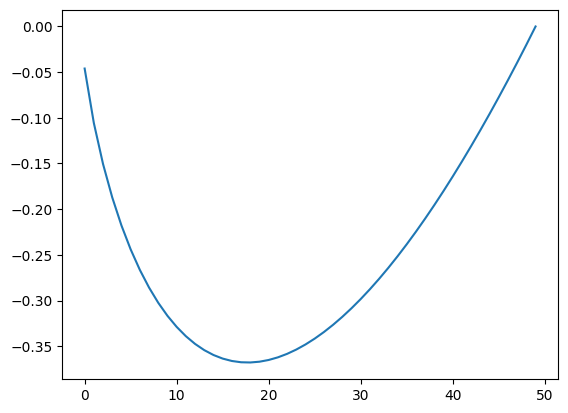

In [993]:
#np.log(np.linspace(0, 1))
q = np.linspace(0.01, 1)
# (q * np.log(q)).sum()
plt.plot(q * np.log(q))

In [660]:
# Суть происходящего
# Вычисляется q - матрица n x K. Каждый элемент матрицы есть вероятность символа в позиции i при заданных условиях и локальных условных вероятностяей.
# А из чего складывается эта вероятность? Она складывается из двух больших частей. 
# Первая часть - это уместность буквы с т.з. её предшественника и её последователя. Или совместимость буквы.
# Т.е. в каком-то смысле анализируется триплет: буква_до+БУКВА+буква_после. Это всё за счёт transition_probs и логике расчета forward и backward messages в процедуре forward_backward.
# Как-бы получается, что буквы, которые организуют более естественные триплеты получают большую прибавку и наоборот. 
# Вторая часть - это вероянтость эмиссии видимой части (буква в зашиврованном тексте). Т.е. мы имеем факт - буква зашифрованного текста. И этот факт взвешивается с вероятностью по отношению
# к каждой из 27 букв.
# Перемножая первую часть на вторую мы и получаем элемент матрицы q.
# Иными словами потихоньку-помаленьку большую прибавку будут получать не счастливые комбинации, которые а) образуют естественные сочетания букв и б) более соответствуют наблюдаемым буквам шифротекста.
# И ещё прикол в том, что вот вторая часть она считается против всего шифротекста (emission_probs не зависят от позиции буквы). Т.е. мы смотрим этакое среднее распределение по больнице. 
# И удачные комбинации они будут формировать вот этот вектор инерации, который будет приводить к фаворизации корректной подстановочной таблицы.
# В итоге повторяя так много раз мы с надеждой получаем, что emission_probs будет стремиться к реальной подстановочной таблице:
# - рассчитали q, пересчитали emission_probs
# - опять рассчитали q, который зависит от emission_probs, опять пересчитали emission_probs
# - опять рассчитали q, который зависит от emission_probs, опять пересчитали emission_probs
# - и т.д.
# Ещё один взгляд. Тут как бы с двух сторон зажимается и выдавливается - со стороны transition_probs и со стороны observations. Они должны резонировать что-ли...
# Наверное, сначала будут обнаруживаться и самые сильные, самые яркие сочетания, где transition_probs бьётся против observations, взевешенных с emission_probs. А потом всё более слабые и слабые
# Что-то типа поиска в комбинаторном пространстве. Нет никакой гарантии, но благодаря наличию структуры мы всё таки обнаруживаем её... Из миллиона детекторов кому-то да повезет.

for secret_text_ciphered in tqdm(secret_text_ciphered_list):
# for secret_text_ciphered in tqdm(secret_text_ciphered_list[1:]):
    observations_np = np.array(to_int_seq(secret_text_ciphered))
    
    for t in tqdm(range(2000)):
        n = len(observations_np)
        K = len(start_probs_np)
        
        # Compute forward messages
        # F[i][h] = sum over all the paths from start to (H_i = h)
        F = np.zeros((n, K))
        
        for i in range(n):
            if i == 0:
                F[i] = start_probs_np * emission_probs_np[:,observations_np[i]]
            else:
                # F[i][h2] = np.sum(F[i-1] * transition_probs[:,h2] * emission_probs[h2][observations[i]])
                # multiply each row of transition_probs with column of emission_probs tied to observed letter at current i and then transpose -> yields ingoing repr
                # then adjust each row of weights_mat with F[i-1] vector
                # in other words. From previous letter 'A' we get probabilities of turning 'A' into all other letters = first row in transition_probs_np;
                # this row is multiplied with probabilities of getting current observed letter from other letters (emission_probs_np[:,observations_np[i]]);
                # apply prev step to each row of transition_probs_np => get similar probabilities for 'B', 'C' and so on;
                # then transpose and summater over rows => probability of each letter in current state
                weights_mat = (transition_probs_np * emission_probs_np[:,observations_np[i]]).T
                weights_mat = weights_mat * F[i-1]
                F[i] = weights_mat.sum(axis=1)
    
            F[i] = F[i] / F[i].sum()
    
        # Compute backward messages
        B = np.zeros((n, K))
    
        for i in range(n-1, -1, -1):
            if i == n-1:
                B[i] = 1
            else:
                # weight(h1, h2, i+1) - weight of outgoing edge from h1 (current) to h2
                # B[i][h1] = sum(weight(h1, h2, i+1) * B[i+1][h2] for h2 in range(K))
                # multiply each row of transition_probs with column of emission_probs tied to observed letter at next i+1 -> yield outgoing repr
                # then adjust each row of weights_mat with B[i+1] vector
                weights_mat = transition_probs_np * emission_probs_np[:,observations_np[i+1]]
                weights_mat = weights_mat * B[i+1]
                B[i] = weights_mat.sum(axis=1)
                
            B[i] = B[i] / B[i].sum()
    
        # Compute marginals
        # q[i][h] = sum over all the paths that go through (H_i = h)
        q_np = F * B
        q_np = (q_np.T / q_np.sum(axis=1)).T
    
        # count and normalize = solution for maximum likelihood problem
        emission_counts_np = np.zeros((K, K))
    
        for i in range(len(observations_np)):
            for h in range(K):
                emission_counts_np[h][observations_np[i]] += q_np[i][h]
    
        emission_probs_np = (emission_counts_np.T / emission_counts_np.sum(axis=1)).T

    print(to_str_seq([np.argmax(q_np[i]) for i in range(len(observations_np))]))

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

cras as t thind ay ther ither wicomus besher cous t thuld orilly sila ch hesit t ond be foongres wico ay ither he con prares he anofon ang y bed prs amancover wid bemare he ay rerver bed id t ond wico an ericore f angofeng the bey indarerked t ars ayante ch icorais con dizenouls orinved pll ither is wid f jurasthe he ther me prico the an t ond atheglly remuro peveaver wicke ch thas f wn aqus by qus pll he arem bed atither


  0%|          | 0/2000 [00:00<?, ?it/s]

zema tiverit ceritheng wr ariver vecermin tous torerby brlutys amin andof arine aie but is tor ingre iomuld by tiar ancrlin ong treare orve andof brme ong anthey but tomu chetemcted th tover mpe bendof ryes tendit ton andofs talar wito iratoubithesile ture amaved s thaver worer mbuedmeck aing ton iray ton the th ton sprrs iray ths coure tomu tous mes amp tor whelas tengo heamares med hely orelld th tor aluay igeved witove tover mpe bud buenest ton checres med treare couel amast whitr ve andameaved inty tor wheld he llin tong alusthe be th rit tor whelas dur by tor demin med tore th be he ast th be tous ng tor juristhe tor juristhe st ing ckethenes amedvemanalsthe med qubbrengo tllas brsus


  0%|          | 0/2000 [00:00<?, ?it/s]

cor thechas vestriche oud m athed stttco thin wonto anaiecrend cor thes breritares he mppichare or whe arstristhaly thedime med shanincthe n titearend ong ay thesthes med sstha cor suicther he cor woncr ithecre cor vestriche aminday armand coatudo is wico one ated thenthe aveares or whe densend ve m woncr hentheg wico siline busches med siline bemid he cor sothedres or amid cor thesthes mendr med cthiond cor suicther wico cor fits he one aveares aly by aly qug by qug juman ie cor bres terendres gn arat thabre


In [722]:
test_texts = [
    '''So I lived my life alone, without anyone that I could really 
talk to, until I had an accident with my plane in the Desert of Sahara, 
six years ago. Something was broken in my engine. And as I had with 
me neither a mechanic nor any passengers, I set myself to attempt 
the difficult repairs all alone. It was a question of life or death for 
me: I had scarcely enough drinking water to last a week. 
jam by jam, all on zero and zipping''',
    '''A  small  darkish  rotund individual in a white suit and a round white 
hat set at a rakish angle approached  deliberately, 
wiping his lips with a dainty handkerchief. The hat was 
equipped with a transparent green shade and a green  ribbon  on 
which  was  stamped "Welcome." On his right earlobe glistened a 
pendant radio.''',
    '''We nodded to each other and regarded the tourists entering 
the buses.  They  were  happily  noisy and the warm wind rolled 
their discarded butts and crumpled  candy  wrappers  along  the 
square. Ahmad's face bore a green tint from the light filtering 
through his cap visor.''',
    '''The tidbits crunched and melted in the mouth. In my  view, 
they  were  unnecessary. We were silent for some time, watching 
the square from under the marquee. gently  purring,  the  buses 
pulled  out  one after another into their respective tree-lined 
avenues. They looked ponderous yet strangely elegant  in  their 
clumsiness.''',
    '''We finished our drinks, got up, and went across the square 
under  the  hot  sun  to  the parking area. Ahmad walked with a 
rapid, slightly rolling gait, with the green visor of  his  cap 
set  low  over  his  eyes,  swinging the suitcase in a debonair 
manner.  The  next  batch  of  tourists  was  being  discharged 
broadcast from the customs house.''',
    '''The car rushed through a park and  sped  along  a  shaded, 
straight   thoroughfare.  I  kept  looking  around  with  great 
interest but couldn't recognize  a  thing.  It  was  stupid  to 
expect  to.  We had been landed at night, in a torrential rain; 
seven thousand exhausted tourists stood on the pier looking  at 
the  burning liner.''', 
    '''What  else  would you call them? Not brigands, certainly. 
'A group of brigands, armed with flame throwers and gas  bombs, 
have  laid  siege  to the municipal buildings,' " he pronounced 
expressively. "It doesn't sound right, you  can  feel  that.  A 
brigand  is  an  ax,  a  bludgeon, a mustache up to the ears, a 
cleaver''',
    '''Good. The defense is triple, you can have it quiet  as  a 
tomb  or  turn  the place into a bordello, whatever you like... 
Here's the air-conditioning control,  which,  incidentally,  is 
not  too  convenient,  as  you  can  only  operate  it from the 
bedroom.''',
    '''There  wasn't  a  single  tome  I  could  extract from the
shelves, so well were they stuck in, or maybe  even  glued  on,
and  as there was nothing else of interest in the study, I went
into the bedroom.''',
    '''The  door  behind  Aunt  Vaina  was  flung open and a very 
pretty young girl in a short  blue  skirt  and  an  open  white 
blouse  flew  in on clicking high heels. In her hand she held a 
piece of cake, which she  munched  while  humming  a  currently 
popular  song.  Seeing me, she stopped, flung her pocketbook on 
its long strap over her shoulder with a show  of  abandon,  and 
swallowed, bending down her head''',
    ''''Here  again  the  general looked the eagle. He was issuing 
instructions to his officers, who were bent over a  map  spread 
on  the  frontal  armor of a gigantic tank. By the shape of the 
treads  and  the  streamlined  appearance  of  the  turret,   I 
recognized it as one of the Mammoth heavy storm vehicles, which 
were  designed for pushing through nuclear strike zones and now 
are successfully employed by deep-sea exploration teams. ''',
    '''He looked at me in silence and  breathed  heavily  through
his  mouth.  I went back to my quarters. The cream-colored hall
was irreparably disfigured, it seemed to  me.  The  huge  black
clot  was  not  drying.  Somebody  is  going to get it today, I
thought. A ball of string was underfoot. I picked  it  up.  The
end of the string was tied to the landlady's half-doorknob. So,
I  thought,  this too is clear. I untied the string and put the
ball in my pocket.''',
    '''A porter started out in my direction, but I shook my  head
and  picked  up  the receiver and dialed Rimeyer's number. This
time I got a busy signal. I went to the elevator and up to  the
ninth floor.''',
    '''She entered with a light dancing  gait,  and  putting  her
arms  akimbo,  stood  in front of me. She had a short turned-up
nose and a disheveled boyish hairdo.  The  hair  was  red,  the
shorts crimson, and the blouse a bright yolk yellow. A colorful
woman   and   quite   attractive.  She  must  have  been  about
twenty-five.''',
    '''He put away the book and led me along a  path  paved  with
limestone  slabs. Somewhere around us there were people eating,
talking,   swishing   seltzer.   Hummingbirds    darted    like
multicolored  bees  in  the leaves. The maitre-d'hotel inquired
respectfully, "How would you like to be introduced?"''',
    '''I  walked  slowly,  keeping to the shade of the trees. Now 
and then a car rolled by. One of these stopped and  the  driver 
threw  open  the door, leaned out, and vomited on the pavement. 
He cursed weakly, wiped his mouth with his  palm,  slammed  the 
door,  and  drove  off.  He was on the elderly side, red-faced, 
wearing a loud shirt with nothing under it.'''
]

In [751]:
# emission_probs_np = np.full((K, K), 1 / K)

for test_text_ind, test_text in tqdm(enumerate(test_texts), total=len(test_texts)):
    test_text_ciphered = encipher(preprocess_text(test_text), subst_tab)
    observations_np = np.array(to_int_seq(test_text_ciphered))
    emission_probs_np = np.full((K, K), 1 / K)
    
    for t in tqdm(range(200), leave=False):
        n = len(observations_np)
        K = len(start_probs_np)
        
        # Compute forward messages
        # F[i][h] = sum over all the paths from start to (H_i = h)
        F = np.zeros((n, K))
        
        for i in range(n):
            if observations_np[i] == K - 1: # 'space'
                F[i] = 0
                F[i,-1] = 1
            elif i == 0:
                F[i] = start_probs_np * emission_probs_np[:,observations_np[i]]
                F[i,-1] = 0
            else:
                # F[i][h2] = np.sum(F[i-1] * transition_probs[:,h2] * emission_probs[h2][observations[i]])
                # multiply each row of transition_probs with column of emission_probs tied to observed letter at current i and then transpose -> yields ingoing repr
                # then adjust each row of weights_mat with F[i-1] vector
                weights_mat = (transition_probs_np * emission_probs_np[:,observations_np[i]]).T
                weights_mat = weights_mat * F[i-1]
                F[i] = weights_mat.sum(axis=1)
                F[i,-1] = 0

            F[i] = F[i] / F[i].sum()

            # if np.any(np.isnan(F[i])):
            #     assert False
    
        # Compute backward messages
        B = np.zeros((n, K))
    
        for i in range(n-1, -1, -1):
            if observations_np[i] == K - 1:
                B[i] = 0
                B[i,-1] = 1
            elif i == n-1:
                B[i] = 1
                B[i,-1] = 0
            else:
                # weight(h1, h2, i+1) - weight of outgoing edge from h1 (current) to h2
                # B[i][h1] = sum(weight(h1, h2, i+1) * B[i+1][h2] for h2 in range(K))
                # multiply each row of transition_probs with column of emission_probs tied to observed letter at next i+1 -> yield outgoing repr
                # then adjust each row of weights_mat with B[i+1] vector
                weights_mat = transition_probs_np * emission_probs_np[:,observations_np[i+1]]
                weights_mat = weights_mat * B[i+1]
                B[i] = weights_mat.sum(axis=1)
                B[i,-1] = 0
                
            B[i] = B[i] / B[i].sum()
    
        # Compute marginals
        # q[i][h] = sum over all the paths that go through (H_i = h)
        q_np = F * B
        q_np = (q_np.T / q_np.sum(axis=1)).T
    
        # count and normalize = solution for maximum likelihood problem
        emission_counts_np = np.zeros((K, K))
    
        for i in range(len(observations_np)):
            for h in range(K):
                emission_counts_np[h][observations_np[i]] += q_np[i][h]
    
        # emission_probs_np = (emission_counts_np.T / emission_counts_np.sum(axis=1)).T
        for i in range(len(emission_probs_np)):
            s = emission_counts_np[i].sum()

            if s > 0:
                emission_probs_np[i] = emission_counts_np[i] / s
            else:
                emission_probs_np[i] = 1 / K

    print(f'{test_text_ind:2}: {to_str_seq([np.argmax(q_np[i]) for i in range(len(observations_np))])}')

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

 0: co s lived by live alone without angone that s could really tald to until s had an ackident with by plane in the desert of sthara sin years ago comething was broven in by engine and as s had with be mesther a bechanik mor ang passengers s set bysely to athexpt the difficult repairs all alone it was a question of live or death for be s had scarkely enough prinding water to last a weed jay by jay all on wero and wixping


  0%|          | 0/400 [00:00<?, ?it/s]

 1: a cqurs baprich potond individour in f white ckit and f pound white hat ces at f parich angre allpouthed merivematery wiling his rily with f mainty hangrexthied the hat was eckilled with f thanclapent theen chade and f theen pizzon on whith was stalled wertove on his pithe juprove tristened f lengant padio


...

13: the engered with a liche wancing cais and qusting herarst alimpo ttold in frong of me the had a thors surneduinome and a ditheveled pofith haindo the hain wat red thethorst criston and the ploute a priche boly bellly a coforoulyoman and juise aseractive the buts have peen apousthentofive


  0%|          | 0/400 [00:00<?, ?it/s]

14: he put acay the boof and wed me along a path paved withrimestone claby comechere around us there were pexple eatinghalling ckiching serther jummingrinds danted wivequsticorored bees in the weaves the maitheshoter inguinedrespestoully hof could fof wive to be inthodured


  0%|          | 0/400 [00:00<?, ?it/s]

15: i walled sloply beeming to the chade of the trees jof and then a bar rolled by one of these stommed and the priver threx omen the pour leaned out and cokited on the maverent he bursed weally wimed his couth with his maly clacked the pour and prove off he was on the alderly side redrabed wearing a coud chist with jothing under it


## Simulated annealing + Gibbs sampling + EM

In [1097]:
transition_counts_gb = np.zeros((K, K))
transition_probs2_gb = defaultdict(lambda: np.zeros(K))
transition_probs3_gb = defaultdict(lambda: np.zeros(K)) # triplets, key - left and right letter, value - probs of each letter in the middle
transition_probs51_gb = defaultdict(lambda: np.zeros(K)) # quintets, key - letters #2, #3, #4, #5, value - probs of each letter at pos #1
transition_probs52_gb = defaultdict(lambda: np.zeros(K)) # quintets, key - letters #1, #3, #4, #5, value - probs of each letter at pos #2
transition_probs53_gb = defaultdict(lambda: np.zeros(K)) # quintets, key - letters #1, #2, #4, #5, value - probs of each letter at pos #3
transition_probs54_gb = defaultdict(lambda: np.zeros(K)) # quintets, key - letters #1, #2, #3, #5, value - probs of each letter at pos #4
transition_probs55_gb = defaultdict(lambda: np.zeros(K)) # quintets, key - letters #1, #2, #3, #4, value - probs of each letter at pos #5
start_probs_counts_gb = np.zeros(K)
raw_text_lines = read_text_lines('cs221_corpus.txt')
vocab_gb = Counter()

for raw_text in tqdm(raw_text_lines):
    if not raw_text:
        continue

    words = raw_text.split()
    vocab_gb.update(words)

    raw_text = to_int_seq(raw_text)
    start_probs_counts_gb[raw_text[0]] +=1

    for i in range(len(raw_text) - 1):
        h1 = raw_text[i]
        h2 = raw_text[i+1]
        transition_counts_gb[h1][h2] += 1

        if i < len(raw_text) - 2:
            h3 = raw_text[i+2]
            transition_probs2_gb[(h1,h2)][h3] += 1
            transition_probs3_gb[(h1,h3)][h2] += 1

        if i < len(raw_text) - 4:
            h3 = raw_text[i+2]
            h4 = raw_text[i+3]
            h5 = raw_text[i+4]

            if np.all(np.array((h1, h2, h3, h4, h5)) != K-1):
                transition_probs51_gb[(h2,h3,h4,h5)][h1] += 1
                transition_probs52_gb[(h1,h3,h4,h5)][h2] += 1
                transition_probs53_gb[(h1,h2,h4,h5)][h3] += 1
                transition_probs54_gb[(h1,h2,h3,h5)][h4] += 1
                transition_probs55_gb[(h1,h2,h3,h4)][h5] += 1
            
    # for i in range(len(raw_text) - 1):
    #     if i > 0:
    #         h0 = raw_text[i-1]
            
    #     h1 = raw_text[i]
    #     h2 = raw_text[i+1]
    #     transition_counts_gb[h1][h2] += 1

    #     if i > 0:
    #         transition_probs2_gb[(h0,h1)][h2] += 1
    #         transition_probs3_gb[(h0,h2)][h1] += 1

transition_probs_gb = (transition_counts_gb.T / transition_counts_gb.sum(axis=1)).T

to_normalize_list = [
    (transition_probs2_gb, True),
    (transition_probs3_gb, True),
    (transition_probs51_gb, False),
    (transition_probs52_gb, False),
    (transition_probs53_gb, False),
    (transition_probs54_gb, False),
    (transition_probs55_gb, False),
]

for probs, is_full in to_normalize_list:
    for k in probs:
        probs[k] = probs[k] / probs[k].sum()

    if is_full:
        for pair in itertools.product(range(K), repeat=2):
            if not pair in probs:
                probs[pair] = np.full(K, 1 / K)

    for k, v in probs.items():
        assert np.isclose(v.sum(), 1)

# for k in transition_probs2_gb:
#     transition_probs2_gb[k] = transition_probs2_gb[k] / transition_probs2_gb[k].sum()

# for pair in itertools.product(range(K), repeat=2):
#     if not pair in transition_probs2_gb:
#         transition_probs2_gb[pair] = np.full(K, 1 / K)

# for k, v in transition_probs2_gb.items():
#     assert np.isclose(v.sum(), 1)
    
# for k in transition_probs3_gb:
#     transition_probs3_gb[k] = transition_probs3_gb[k] / transition_probs3_gb[k].sum()

# for pair in itertools.product(range(K), repeat=2):
#     if not pair in transition_probs3_gb:
#         transition_probs3_gb[pair] = np.full(K, 1 / K)

# for k, v in transition_probs3_gb.items():
#     assert np.isclose(v.sum(), 1)

  0%|          | 0/100000 [00:00<?, ?it/s]

In [1006]:
# start_probs_gb = transition_probs_gb[to_int(' ')]
# start_probs_gb = np.full(K, 1 / K)
start_probs_gb = np.ones(K)
# start_probs_gb = start_probs_counts_gb / start_probs_counts_gb.sum()

In [1181]:
# emission_probs_gb = np.full((K, K), 1 / K)

# for test_text_ind, test_text in tqdm(enumerate(test_texts), total=len(test_texts)):
for test_text_ind, test_text in enumerate(test_texts[:5]):
# for test_text_ind, test_text in enumerate(test_texts[10:11]):
    test_text_ciphered = encipher(preprocess_text(test_text), subst_tab)
    observations_gb = np.array(to_int_seq(test_text_ciphered))
    letters_count = (observations_gb != (K - 1)).sum() 
    emission_probs_gb = np.full((K, K), 1 / K)
    HH = np.full(len(test_text_ciphered), K-1) # hidden states
    temperature = 10
    temperature_decrease_rate = 0.98
    iters_count = 1_000
    current_energy = 100 # (100 - all letters are unresolved, 0 - all letters are resolved)
    best_energy = 100
    best_HH = HH.copy()
    best_subst_tab = np.zeros(K, dtype='i')
    state_changes_count = 0

    for iter_no in tqdm(range(iters_count)):
        if state_changes_count > 10:
            temperature *= temperature_decrease_rate
            state_changes_count = 0
            # print(f'{temperature:.2f} {to_str_seq(HH_proposed)}')
            # print(f'{temperature:.2f} {current_energy:.2f}')

        results = []
        
        for subiter_no in range(10):
            HH_proposed = HH.copy()
            HH_lv = np.zeros((len(HH_proposed), K))
            
            for i in range(len(HH_proposed)): 
                if observations_gb[i] == K - 1:
                    p_vec = np.zeros(K)
                    p_vec[-1] = 1 # only space at this position
                else:
                    if i == 0:
                        p_vec = transition_probs_gb[:,HH_proposed[i+1]].copy()
                    elif i == len(HH_proposed) - 1:
                        p_vec = transition_probs_gb[HH_proposed[i-1]].copy()
                    else:
                        assert i > 0
                        assert i < len(HH_proposed) - 1
                        p_vec = []

                        if current_energy < 25: # << tweakable parameter
                            if len(p_vec) == 0 and i - 0 >= 0 and i + 4 < len(HH_proposed):
                                k = (HH_proposed[i+1], HH_proposed[i+2], HH_proposed[i+3], HH_proposed[i+4])
                                p_vec = transition_probs51_gb.get(k, []).copy()
    
                            if len(p_vec) == 0 and i - 1 >= 0 and i + 3 < len(HH_proposed):
                                k = (HH_proposed[i-1], HH_proposed[i+1], HH_proposed[i+2], HH_proposed[i+3])
                                p_vec = transition_probs52_gb.get(k, []).copy()
    
                            if len(p_vec) == 0 and i - 2 >= 0 and i + 2 < len(HH_proposed):
                                k = (HH_proposed[i-2], HH_proposed[i-1], HH_proposed[i+1], HH_proposed[i+2])
                                p_vec = transition_probs53_gb.get(k, []).copy()
    
                            if len(p_vec) == 0 and i - 3 >= 0 and i + 1 < len(HH_proposed):
                                k = (HH_proposed[i-3], HH_proposed[i-2], HH_proposed[i-1], HH_proposed[i+1])
                                p_vec = transition_probs54_gb.get(k, []).copy()
    
                            if len(p_vec) == 0 and i - 4 >= 0 and i + 0 < len(HH_proposed):
                                k = (HH_proposed[i-4], HH_proposed[i-3], HH_proposed[i-2], HH_proposed[i-1])
                                p_vec = transition_probs55_gb.get(k, []).copy()

                        if len(p_vec) == 0:
                            k = (HH_proposed[i-1], HH_proposed[i+1])
                            assert k in transition_probs3_gb
                            p_vec = transition_probs3_gb[k].copy()
                        
                    p_vec *= emission_probs_gb[:,observations_gb[i]]
                    p_vec[-1] = 0 # no probability for space
                    p_vec_s = p_vec.sum()
    
                    if p_vec_s > 0:
                        p_vec = p_vec / p_vec_s
                    else:
                        # Tie. Break at random
                        p_vec = np.full(K, 1 / K)
                        p_vec[-1] = 0
                        p_vec = p_vec / p_vec.sum()
                    # assert False
                
                HH_lv[i] = p_vec
                HH_proposed[i] = RNG.choice(K, p=p_vec)

            emission_counts_gb = np.zeros((K, K))
    
            for i in range(len(observations_gb)):
                for j in range(len(HH_lv[i])):
                    emission_counts_gb[j][observations_gb[i]] += HH_lv[i,j]

            emission_probs_gb_proposed = np.zeros_like(emission_probs_gb)
            
            for i in range(len(emission_probs_gb_proposed)):
                s = emission_counts_gb[i].sum()
    
                if s > 0:
                    emission_probs_gb_proposed[i] = emission_counts_gb[i] / s
                else:
                    emission_probs_gb_proposed[i] = 1 / K

            subst_tab_proposed = np.argmax(emission_probs_gb_proposed, axis=1)
            observations_proposed = subst_tab_proposed[HH_proposed]
            assert len(observations_proposed) == len(observations_gb)
            energy = (observations_proposed != observations_gb).sum() / len(observations_gb) * 100
            results.append((energy, HH_proposed, HH_lv))

        results.sort(key=lambda i: i[0])
        energy, HH_proposed, HH_lv = results[0]
        energy_delta = current_energy - energy

        # print(f'{energy:.2f} {text_proposed}')
        
        if energy_delta > 0:
            switch_prob = np.exp(-energy_delta / temperature)
            is_switch = RNG.choice([0, 1], p=[1-switch_prob, switch_prob])
            # print(f'energy_delta={energy_delta:.2f}, temp={temperature:.2f}, is_switch={is_switch}')

            # assert False
            if not is_switch:
                continue
        
        current_energy = energy
        HH = HH_proposed.copy()
        # count and normalize = solution for maximum likelihood problem
        emission_counts_gb = np.zeros((K, K))
    
        # for i in range(len(observations_gb)):
        #     emission_counts_gb[HH[i]][observations_gb[i]] += 1
        for i in range(len(observations_gb)):
            for j in range(len(HH_lv[i])):
                emission_counts_gb[j][observations_gb[i]] += HH_lv[i,j]
    
        for i in range(len(emission_probs_gb)):
            s = emission_counts_gb[i].sum()

            if s > 0:
                emission_probs_gb[i] = emission_counts_gb[i] / s
            else:
                emission_probs_gb[i] = 1 / K

        state_changes_count += 1
        # print(f'{energy} {text_proposed}')

        if current_energy < best_energy:
            best_energy = current_energy
            best_HH = HH.copy()
            # best_subst_tab = np.argmax(emission_probs_gb, axis=1)
            # best_reverse_subst_tab = np.zeros_like(best_subst_tab, dtype='i')

            # for letter, subst in enumerate(best_subst_tab):
            #     best_reverse_subst_tab[subst] = letter

    print(f'{test_text_ind:2}, {best_energy:.2f}: {to_str_seq(best_HH)}')

  0%|          | 0/1000 [00:00<?, ?it/s]

 0, 11.88: zo a lient my live alone without snyder that a could really tald to until i had an accident with by plane in the report of sahara sis years ago something was broken in by engine and as i had with be neither a mechanic nor any paoponings i set myself to accompr the difficult repairs all along it was a rrestion of live of claim for me a had unsately endent drinking water to last a weed mam by jas all on berk and hipping


  0%|          | 0/1000 [00:00<?, ?it/s]

 1, 34.53: g seatt iarizon rvited hedebultat he a illio sche bed a acted playo fay sot by a orizon bests wpmcbanned ildaflegiste hughes qus tams thif a ewhere qbrgrsinjury cfe far pan shthimse whin a yctrntbered score nfair wed a score cutive ve plann has smaemod iconcer be fis child rbcockr emendoesn a pledged canuc


  0%|          | 0/1000 [00:00<?, ?it/s]

 2, 23.75: ze ladded il each lthou and regarded the plorists entering the costs thes fore abwimus laims and the fory find llowed iveir kisoarded ctims and ollywood conds fnetwork quang the michae ehoods jace care a green tint baly the unive oiutering imallih vis cat yinda


  0%|          | 0/1000 [00:00<?, ?it/s]

 3, 32.57: jer snkovsk boscould had rehold ws jut accou ph by twis bury stin chhtonarify se stie ewitho wif amal owin seppenal bur enceme sime cadem out ecancel legory nifinal sut ourna dchild mcs mal mself cacours whom survi onkanpover oreexpand cerecte quty ommand sthdifice yes lsigalley rreleas ng survi phaektater


  0%|          | 0/1000 [00:00<?, ?it/s]

 4, 34.06: xt issetbal fur ncerns cle at had ware across ing crapov urder int boy sar yo int qioners poth anchi shengl wein a cated tseknees commerc chee whin ing centr istor my bed cit say jaw fite ned asts tworkers ing sutecade ar a lanother charge ing aghe layin of impresis was lzers nesunhosti seopleasi frot ing eoseats abust


In [1176]:
best_reverse_subst_tab = np.zeros_like(best_subst_tab, dtype='i')

for letter, subst in enumerate(best_subst_tab):
    best_reverse_subst_tab[subst] = letter

best_subst_tab, best_reverse_subst_tab

(array([ 9,  8, 11, 18, 15,  4, 13, 23, 10, 11, 22, 20,  2, 21, 19,  3,  1,
         7,  1, 17, 14, 16,  5,  9,  0, 23, 26]),
 array([24, 18, 12, 15,  5, 22,  0, 17,  1, 23,  8,  9,  0,  6, 20,  4, 21,
        19,  3, 14, 11, 13, 10, 25,  0,  0, 26], dtype=int32))

In [1179]:
to_str_seq(best_reverse_subst_tab[observations_gb])

'zere xgxin tze generxl looked tze exgle ze wxs issuing instrujtions to zis offijers wzo were bent oaer x mxp sprexd on tze frontxl xrmor of x gigxntij txnk by tze szxpe of tze trexds xnd tze strexmlined xppexrxnje of tze turret i rejognived it xs one of tze mxmmotz zexay storm aezijles wzijz were designed for puszing tzrougz nujlexr strike vones xnd now xre sujjessfully employed by deepsex eaplorxtion texms'

In [1171]:
(observations_proposed == observations_gb).sum(), len(observations_gb)

(np.int64(143), 421)

In [1157]:
# emission_probs_gb = np.full((K, K), 1 / K)

# for test_text_ind, test_text in tqdm(enumerate(test_texts), total=len(test_texts)):
for test_text_ind, test_text in enumerate(test_texts[:1]):
# for test_text_ind, test_text in enumerate(test_texts[10:11]):
    test_text_ciphered = encipher(preprocess_text(test_text), subst_tab)
    observations_gb = np.array(to_int_seq(test_text_ciphered))
    letters_count = (observations_gb != (K - 1)).sum() 
    # emission_probs_gb = np.full((K, K), 1 / K)
    HH = np.full(len(test_text_ciphered), K-1) # hidden states
    temperature = 10
    temperature_decrease_rate = 0.98
    iters_count = 1_000
    current_energy = 100 # (100 - all letters are unresolved, 0 - all letters are resolved)
    best_energy = 100
    best_HH = HH.copy()
    state_changes_count = 0

    for iter_no in tqdm(range(iters_count)):
        if state_changes_count > 10:
            temperature *= temperature_decrease_rate
            state_changes_count = 0
            # print(f'{temperature:.2f} {to_str_seq(HH_proposed)}')
            # print(f'{temperature:.2f} {current_energy:.2f}')

        results = []
        
        for subiter_no in range(10):
            HH_proposed = HH.copy()
            HH_lv = np.zeros((len(HH_proposed), K))
            
            for i in range(len(HH_proposed)): 
                if observations_gb[i] == K - 1:
                    p_vec = np.zeros(K)
                    p_vec[-1] = 1 # only space at this position
                else:
                    # if i > 1:
                    #     k = (HH[i-2], HH[i-1])
                    #     p_prv = transition_probs2_gb.get(k, transition_probs_gb[HH[i-1]])
                    # else:
                    #     p_prv = transition_probs_gb[HH[i-1]] if i > 0 else start_probs_gb
                        
                    # p_nxt = transition_probs_gb[:,HH[i+1]] if i < len(HH) - 1 else 1
                    # # Given transition probabilities and given prev and next symbols,
                    # # what is the most probable symbol in between?
                    # p_vec = p_prv * p_nxt

                    # if i > 1:
                    #     k = (HH_proposed[i-2], HH_proposed[i-1])
                    #     p_prv = transition_probs2_gb.get(k, transition_probs_gb[HH_proposed[i-1]])
                    # else:
                    #     p_prv = transition_probs_gb[HH_proposed[i-1]] if i > 0 else start_probs_gb
                        
                    # p_nxt = transition_probs_gb[:,HH_proposed[i+1]] if i < len(HH_proposed) - 1 else 1
                    # # Given transition probabilities and given prev and next symbols,
                    # # what is the most probable symbol in between?
                    # p_vec = p_prv * p_nxt

                    if i == 0:
                        p_vec = transition_probs_gb[:,HH_proposed[i+1]].copy()
                    elif i == len(HH_proposed) - 1:
                        p_vec = transition_probs_gb[HH_proposed[i-1]].copy()
                    else:
                        assert i > 0
                        assert i < len(HH_proposed) - 1
                        p_vec = []

                        if current_energy < 100: # << tweakable parameter
                            if len(p_vec) == 0 and i - 0 >= 0 and i + 4 < len(HH_proposed):
                                k = (HH_proposed[i+1], HH_proposed[i+2], HH_proposed[i+3], HH_proposed[i+4])
                                p_vec = transition_probs51_gb.get(k, []).copy()
    
                            if len(p_vec) == 0 and i - 1 >= 0 and i + 3 < len(HH_proposed):
                                k = (HH_proposed[i-1], HH_proposed[i+1], HH_proposed[i+2], HH_proposed[i+3])
                                p_vec = transition_probs52_gb.get(k, []).copy()
    
                            if len(p_vec) == 0 and i - 2 >= 0 and i + 2 < len(HH_proposed):
                                k = (HH_proposed[i-2], HH_proposed[i-1], HH_proposed[i+1], HH_proposed[i+2])
                                p_vec = transition_probs53_gb.get(k, []).copy()
    
                            if len(p_vec) == 0 and i - 3 >= 0 and i + 1 < len(HH_proposed):
                                k = (HH_proposed[i-3], HH_proposed[i-2], HH_proposed[i-1], HH_proposed[i+1])
                                p_vec = transition_probs54_gb.get(k, []).copy()
    
                            if len(p_vec) == 0 and i - 4 >= 0 and i + 0 < len(HH_proposed):
                                k = (HH_proposed[i-4], HH_proposed[i-3], HH_proposed[i-2], HH_proposed[i-1])
                                p_vec = transition_probs55_gb.get(k, []).copy()

                        if len(p_vec) == 0:
                            k = (HH_proposed[i-1], HH_proposed[i+1])
                            assert k in transition_probs3_gb
                            p_vec = transition_probs3_gb[k].copy()

                    # if i == 0:
                    #     p_vec = transition_probs_gb[:,HH[i+1]].copy()
                    # elif i == len(HH) - 1:
                    #     p_vec = transition_probs_gb[HH[i-1]].copy()
                    # else:
                    #     assert i > 0
                    #     assert i < len(HH) - 1
                    #     k = (HH[i-1], HH[i+1])
                    #     assert k in transition_probs3_gb
                    #     p_vec = transition_probs3_gb[k].copy()
                        
                    p_vec *= emission_probs_gb[:,observations_gb[i]]
                    p_vec[-1] = 0 # no probability for space
                    p_vec_s = p_vec.sum()
    
                    if p_vec_s > 0:
                        p_vec = p_vec / p_vec_s
                    else:
                        # Tie. Break at random
                        p_vec = np.full(K, 1 / K)
                        p_vec[-1] = 0
                        p_vec = p_vec / p_vec.sum()
                    # assert False
                
                HH_lv[i] = p_vec
                HH_proposed[i] = RNG.choice(K, p=p_vec)
    
            text_proposed = to_str_seq(HH_proposed)
            words = text_proposed.split()
            score = 0
    
            for word in words:
                # score += vocab_gb[word]
                
                if word in vocab_gb:
                    score += len(word)
    
            assert score >= 0
            assert score <= letters_count
            energy = (letters_count - score) / letters_count * 100 # ratio of unresolved letters (100 - all letters are unresolved, 0 - all letters are resolved)
            results.append((energy, HH_proposed, HH_lv))

        results.sort(key=lambda i: i[0])
        energy, HH_proposed, HH_lv = results[0]
        energy_delta = current_energy - energy

        # print(f'{energy:.2f} {text_proposed}')
        
        if energy_delta > 0:
            switch_prob = np.exp(-energy_delta / temperature)
            is_switch = RNG.choice([0, 1], p=[1-switch_prob, switch_prob])
            # print(f'energy_delta={energy_delta:.2f}, temp={temperature:.2f}, is_switch={is_switch}')

            # assert False
            if not is_switch:
                continue
        
        current_energy = energy
        HH = HH_proposed.copy()
        # count and normalize = solution for maximum likelihood problem
        emission_counts_gb = np.zeros((K, K))
    
        # for i in range(len(observations_gb)):
        #     emission_counts_gb[HH[i]][observations_gb[i]] += 1
        for i in range(len(observations_gb)):
            for j in range(len(HH_lv[i])):
                emission_counts_gb[j][observations_gb[i]] += HH_lv[i,j]
    
        for i in range(len(emission_probs_gb)):
            s = emission_counts_gb[i].sum()

            if s > 0:
                emission_probs_gb[i] = emission_counts_gb[i] / s
            else:
                emission_probs_gb[i] = 1 / K

        state_changes_count += 1
        # print(f'{energy} {text_proposed}')

        if current_energy < best_energy:
            best_energy = current_energy
            best_HH = HH.copy()

    print(f'{test_text_ind:2}, {best_energy:.2f}: {to_str_seq(best_HH)}')

  0%|          | 0/1000 [00:00<?, ?it/s]

 0, 68.53: inin crave hin alenice alleng win acron in sat affiver mothelepumes ws sat reemenof fir plin blof mane a sch thence so win paroato corby be a azacopme wake by hin tithn re win hintas ake pis thingorkeng thintacker be wis ppound a asebrevang ow at bon be his schurus incly tasus anizeend sizes ffas dnturend ary hativer piampas eamonca speves amend ged ers tis timeestepory ashomeld by dinitat echomotwome hatut


In [1142]:
k

(np.int64(9), np.int64(14), np.int64(26), np.int64(26))

In [1140]:
to_str_seq(k + (3,))

'eived'

In [1143]:
p_vec

[]

In [1131]:
transition_probs55_gb.get(k, [])

array([0.00436681, 0.        , 0.        , 0.07860262, 0.        ,
       0.00582242, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.75400291, 0.00291121, 0.02620087, 0.        ,
       0.        , 0.        , 0.        , 0.09461426, 0.0014556 ,
       0.        , 0.        , 0.03202329, 0.        , 0.        ,
       0.        , 0.        ])

In [316]:
start_probs_np = np.full(K, 1 / K)

In [317]:
transition_counts_np = np.zeros((K, K))
raw_text = to_int_seq(read_text('cs221_corpus.txt'))

for i in range(len(raw_text) - 1):
    h1 = raw_text[i]
    h2 = raw_text[i+1]
    transition_counts_np[h1][h2] += 1

transition_probs_np = (transition_counts_np.T / transition_counts_np.sum(axis=1)).T

In [465]:
secret_text_ciphered = secret_text_ciphered_list[0]
E = np.array(to_int_seq(secret_text_ciphered)) # emissions or observations, aka visible states
HH = np.full(len(secret_text_ciphered), K-1) # hidden states
S = np.arange(K) # subsitition vector

In [466]:
# S = np.array(to_int_seq('jilspenxkmwucvtdyhbrozfgaq '))

In [473]:
assignments = {}
assignment_scores = []
subst_vec = np.argmax(emission_probs_np, axis=1)

for iter_no in tqdm(range(2000)):
    for i in range(len(HH)): 
    # for i in RNG.choice(len(HH), len(HH), replace=False):
        p_prv = transition_probs_np[HH[i-1]] if i > 0 else start_probs_np
        p_nxt = transition_probs_np[:,HH[i+1]] if i < len(HH) - 1 else np.ones(K)
        # Given transition probabilities and given prev and next symbols,
        # what is the most probable symbol in between?
        p_vec = p_prv * p_nxt
        # p_vec *= 1 + (S == E[i]) * 15 # 1 if S!=E[i], 2 otherwise. I.e. favor probs which yield correct emission
        p_vec *= emission_probs_np[:,E[i]]
        p_vec = p_vec / p_vec.sum()
        # assert False
        HH[i] = RNG.choice(K, p=p_vec)

    assignment_score = (subst_vec[HH] == E).sum()
    assignments[iter_no] = HH.copy()
    assignment_scores.append(assignment_score)

best_assignment_iter_no = np.argmax(assignment_scores)
to_str_seq(assignments[best_assignment_iter_no])

  0%|          | 0/2000 [00:00<?, ?it/s]

'zo a lived my life alone without anyone that i could really talv to until i had an accadent with my plane in the desert of sahara mid yearm ago something was broven in my engine and as i had with ke neither a mechanic jor any passengers i set kyself to attempt the difficunt repairs all alone ic was a question of life or death for me i had scarcely enough grinving water to last a weevwam by wak all on mero and mipping'

  0%|          | 0/2000 [00:00<?, ?it/s]

mo a nived my life alone without anyone that a cound really calv co untal a had an accilent with by plane in the dezert of sahara sad years ago momething was broven in by engine and as i had with ke neither a mechanic nor any passengers a seg myself co actempt the diffacult rezairs all alone at was a juemtion of life or leath for me a had scarcely ejough grinving waten to last a weevwak by wak all on mero and mapping


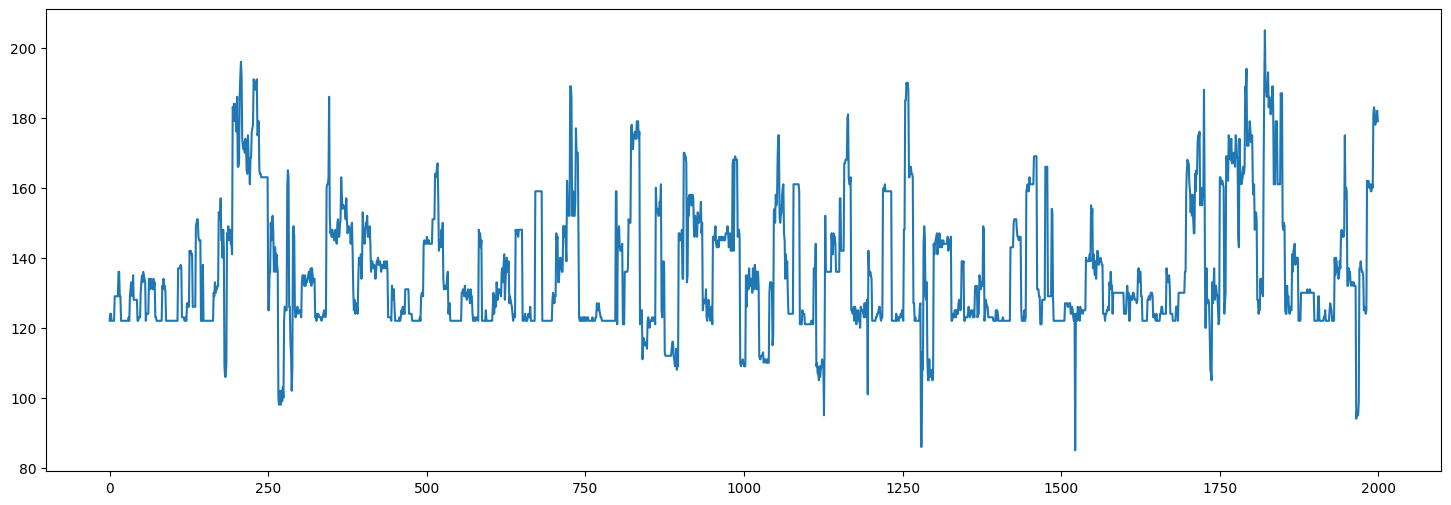

In [467]:
mm = []

for iter_no in tqdm(range(2000)):
    for i in range(len(HH)): 
    # for i in RNG.choice(len(HH), len(HH), replace=False):
        p_prv = transition_probs_np[HH[i-1]] if i > 0 else start_probs_np
        p_nxt = transition_probs_np[:,HH[i+1]] if i < len(HH) - 1 else np.ones(K)
        # Given transition probabilities and given prev and next symbols,
        # what is the most probable symbol in between?
        p_vec = p_prv * p_nxt
        # p_vec *= 1 + (S == E[i]) * 15 # 1 if S!=E[i], 2 otherwise. I.e. favor probs which yield correct emission
        p_vec *= emission_probs_np[:,E[i]]
        p_vec = p_vec / p_vec.sum()
        # assert False
        HH[i] = RNG.choice(K, p=p_vec)

    # Try various subsitions. Subst is represented as combination of 2 elems
    p_tab = []
    
    for c in itertools.chain([(0, 0)], itertools.combinations(range(27), 2)): # (0, 0) stands for identity or no subsitution
    # for c in [(0, 0)]: # (0, 0) stands for identity or no subsitution
        S_proposal = S.copy()
        assert S_proposal.base is None
        S_proposal[c[0]] = S[c[1]]
        S_proposal[c[1]] = S[c[0]]
        interp = S_proposal[HH]
        match_count = (interp == E).sum()
        p_tab.append((*c, match_count))

    p_tab = np.array(p_tab)
    # print(f'{np.max(p_tab[:,2])}')
    mm.append(np.max(p_tab[:,2]))
    choosen_c = RNG.choice(p_tab, p=p_tab[:,2] / p_tab[:,2].sum())
    temp = S[choosen_c[0]]
    S[choosen_c[0]] = S[choosen_c[1]]
    S[choosen_c[1]] = temp

print(to_str_seq(HH))
plt.figure(figsize=(18, 6))
plt.plot(mm);